# Hero Run + Qualitative Visuals (YOLO vs Faster R-CNN)

This notebook does four things:
1. Loads the **best YOLO** and **best Faster R-CNN** checkpoints (ResNet-50 + SGD).
2. Runs inference on the **same fixed validation images** and saves visualizations (before extra training).
3. Optionally continues training both models to a longer schedule ("hero" run).
4. Reruns inference on the exact same images and saves side-by-side comparisons (after extra training).

## Split Strategy Notes (Train / Val / Test)

- Your current setup uses **train + validation** (from COCO 2017 under your local `fiftyone/coco-2017` path).
- You currently do **not** appear to have a separate test split in this project workflow.
- For COCO-sized datasets, full k-fold cross-validation is usually not required for class projects because it is expensive.
- Strong practical approach:
  - Use train/val for model development and selection.
  - Keep a small held-out test subset only for final once-only reporting, if available.
- If you cannot create a true test set, report this as a limitation and avoid over-claiming generalization.

In [1]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.ops import nms
from torchvision.utils import draw_bounding_boxes
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.transforms import functional as TF

from pycocotools.coco import COCO
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [2]:
# -----------------------------
# Paths and experiment settings
# -----------------------------
WORK_DIR = Path.cwd()
RUNS_DIR = WORK_DIR / 'runs'
SUMMARY_CSV = RUNS_DIR / 'summary_results.csv'

# Matches your existing comparison notebook default
COCO_ROOT = Path.home() / 'fiftyone' / 'coco-2017'
TRAIN_IMG_DIR = COCO_ROOT / 'train' / 'data'
TRAIN_ANN = COCO_ROOT / 'train' / 'labels.json'
VAL_IMG_DIR = COCO_ROOT / 'validation' / 'data'
VAL_ANN = COCO_ROOT / 'validation' / 'labels.json'

YOLO_RUN_DIR = RUNS_DIR / 'detect' / 'runs' / 'yolo_resnet50_sgd' / 'train'
YOLO_BEST = YOLO_RUN_DIR / 'weights' / 'best.pt'
YOLO_LAST = YOLO_RUN_DIR / 'weights' / 'last.pt'
YOLO_DATA_YAML = RUNS_DIR / 'yolo_resnet50_sgd' / 'yolo_data' / 'data.yaml'
YOLO_VAL_IMAGES = RUNS_DIR / 'yolo_resnet50_sgd' / 'yolo_data' / 'val' / 'images'

FRCNN_CKPT = RUNS_DIR / 'fasterrcnn_resnet50_sgd' / 'checkpoints' / 'latest.pt'

VIS_DIR = RUNS_DIR / 'qualitative_hero'
BEFORE_DIR = VIS_DIR / 'before'
AFTER_DIR = VIS_DIR / 'after'
PANEL_DIR = VIS_DIR / 'panels'
for d in [VIS_DIR, BEFORE_DIR, AFTER_DIR, PANEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

NUM_VIS_IMAGES = 4
IMG_SIZE = 512
YOLO_CONF = 0.25
FRCNN_CONF = 0.40

# Hero run: continue from prior 10-epoch run to 30 total epochs
BASE_EPOCHS = 10
HERO_TOTAL_EPOCHS = 30
FRCNN_BATCH = 2
FRCNN_EXTRA_LR = 5e-4

print('Summary exists:', SUMMARY_CSV.exists())
print('YOLO best exists:', YOLO_BEST.exists())
print('FRCNN checkpoint exists:', FRCNN_CKPT.exists())
print('COCO val images exists:', VAL_IMG_DIR.exists())

Summary exists: True
YOLO best exists: True
FRCNN checkpoint exists: True
COCO val images exists: True


In [3]:
# Optional: confirm best configs from summary table
if SUMMARY_CSV.exists():
    df = pd.read_csv(SUMMARY_CSV)
    df_ok = df[df['status'] == 'ok'].copy()
    best_yolo = df_ok[df_ok['family'] == 'yolo'].sort_values('ap', ascending=False).head(1)
    best_frcnn = df_ok[df_ok['family'] == 'fasterrcnn'].sort_values('ap', ascending=False).head(1)
    print('Best YOLO row:')
    display(best_yolo)
    print('Best Faster R-CNN row:')
    display(best_frcnn)
else:
    print('summary_results.csv not found; using configured checkpoint paths directly.')

Best YOLO row:


,family,backbone,optimizer,status,train_seconds,ap,ap50,ap75,phase,run_index,effective_batch_size,effective_image_size,wall_seconds,resumed,resume_from,checkpoint_path,latency_ms
1,yolo,resnet50,sgd,ok,812.20811,0.363869,0.512213,0.383012,sanity-fast,2,4,512,828.6833,False,NaN,NaN,NaN


Best Faster R-CNN row:


,family,backbone,optimizer,status,train_seconds,ap,ap50,ap75,phase,run_index,effective_batch_size,effective_image_size,wall_seconds,resumed,resume_from,checkpoint_path,latency_ms
0,fasterrcnn,resnet50,sgd,ok,1538.125046,0.118884,0.253086,0.094291,sanity-fast,1,2,512,1568.663881,NaN,NaN,NaN,NaN


In [4]:
# -----------------------
# Common helper functions
# -----------------------
def choose_fixed_images(val_dir: Path, n: int = 4, seed: int = 42):
    files = sorted(list(val_dir.glob('*.jpg')) + list(val_dir.glob('*.png')) + list(val_dir.glob('*.jpeg')))
    if len(files) == 0:
        raise FileNotFoundError(f'No images found in {val_dir}')
    rng = random.Random(seed)
    if len(files) <= n:
        return files
    return rng.sample(files, n)

def load_coco_category_names(ann_path: Path):
    if not ann_path.exists():
        return {}
    with open(ann_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    out = {}
    for c in data.get('categories', []):
        out[int(c['id'])] = c['name']
    return out

def show_triplets(orig_paths, yolo_images, frcnn_images, title):
    rows = len(orig_paths)
    fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)
    for i in range(rows):
        orig = np.array(Image.open(orig_paths[i]).convert('RGB'))
        axes[i, 0].imshow(orig)
        axes[i, 0].set_title(f'Original: {orig_paths[i].name}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(yolo_images[i])
        axes[i, 1].set_title('YOLO')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(frcnn_images[i])
        axes[i, 2].set_title('Faster R-CNN')
        axes[i, 2].axis('off')

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [5]:
# ------------------------------------
# Load best YOLO and Faster R-CNN models
# ------------------------------------
COCO_NAMES = load_coco_category_names(VAL_ANN)

# Map contiguous COCO80 ids (YOLO/FRCNN head) back to sparse COCO category ids.
COCO80_TO_91 = [
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 13, 14, 15, 16, 17, 18, 19, 20, 21,
    22, 23, 24, 25, 27, 28, 31, 32, 33, 34,
    35, 36, 37, 38, 39, 40, 41, 42, 43, 44,
    46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
    56, 57, 58, 59, 60, 61, 62, 63, 64, 65,
    67, 70, 72, 73, 74, 75, 76, 77, 78, 79,
    80, 81, 82, 84, 85, 86, 87, 88, 89, 90,
]

def build_frcnn_resnet50(num_classes=81, image_size=512):
    backbone = resnet_fpn_backbone('resnet50', weights='DEFAULT', trainable_layers=2)
    model = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        min_size=image_size,
        max_size=image_size,
        rpn_pre_nms_top_n_train=1000,
        rpn_post_nms_top_n_train=500,
        rpn_post_nms_top_n_test=500,
    )
    return model

# YOLO
if not YOLO_BEST.exists():
    raise FileNotFoundError(f'YOLO checkpoint not found: {YOLO_BEST}')
yolo_model = YOLO(str(YOLO_BEST))

# Faster R-CNN
if not FRCNN_CKPT.exists():
    raise FileNotFoundError(f'Faster R-CNN checkpoint not found: {FRCNN_CKPT}')
frcnn_ckpt = torch.load(FRCNN_CKPT, map_location='cpu')
frcnn_model = build_frcnn_resnet50(num_classes=81, image_size=IMG_SIZE)
state = frcnn_ckpt['model'] if isinstance(frcnn_ckpt, dict) and 'model' in frcnn_ckpt else frcnn_ckpt
missing, unexpected = frcnn_model.load_state_dict(state, strict=False)
print('FRCNN missing keys:', len(missing), '| unexpected keys:', len(unexpected))
frcnn_model.to(DEVICE).eval()

c:\Users\Magz8\anaconda3\envs\cogs185\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


FRCNN missing keys: 0 | unexpected keys: 0


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(512,), max_size=512, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu)

In [6]:
# -----------------------------
# Inference helper functions
# -----------------------------
COCO80_TO_91 = [
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 13, 14, 15, 16, 17, 18, 19, 20, 21,
    22, 23, 24, 25, 27, 28, 31, 32, 33, 34,
    35, 36, 37, 38, 39, 40, 41, 42, 43, 44,
    46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
    56, 57, 58, 59, 60, 61, 62, 63, 64, 65,
    67, 70, 72, 73, 74, 75, 76, 77, 78, 79,
    80, 81, 82, 84, 85, 86, 87, 88, 89, 90,
]

def infer_yolo_on_image(model, image_path: Path, conf=0.25):
    res = model.predict(source=str(image_path), conf=conf, verbose=False)[0]
    img_bgr = res.plot(line_width=2)
    img_rgb = img_bgr[..., ::-1]
    return img_rgb

@torch.inference_mode()
def infer_frcnn_on_image(model, image_path: Path, category_names, score_thresh=0.4, iou_thresh=0.5):
    pil = Image.open(image_path).convert('RGB')
    tensor_u8 = TF.pil_to_tensor(pil)
    inp = tensor_u8.float() / 255.0

    out = model([inp.to(DEVICE)])[0]
    boxes = out['boxes'].detach().cpu()
    scores = out['scores'].detach().cpu()
    labels = out['labels'].detach().cpu()

    keep = scores >= score_thresh
    boxes, scores, labels = boxes[keep], scores[keep], labels[keep]

    if len(boxes) > 0:
        keep_nms = nms(boxes, scores, iou_thresh)
        boxes, scores, labels = boxes[keep_nms], scores[keep_nms], labels[keep_nms]

    if len(boxes) == 0:
        return tensor_u8.permute(1, 2, 0).numpy()

    label_text = []
    for cid, s in zip(labels.tolist(), scores.tolist()):
        if int(cid) <= 0 or int(cid) > len(COCO80_TO_91):
            cname = str(int(cid))
        else:
            sparse_id = COCO80_TO_91[int(cid) - 1]
            cname = category_names.get(int(sparse_id), str(int(sparse_id)))
        label_text.append(f'{cname} {s:.2f}')

    rendered = draw_bounding_boxes(
        tensor_u8,
        boxes=boxes,
        labels=label_text,
        colors='red',
        width=2,
        font_size=14,
    )
    return rendered.permute(1, 2, 0).numpy()

Fixed images:
- 000000356432.jpg
- 000000055299.jpg
- 000000008532.jpg
- 000000428218.jpg


c:\Users\Magz8\anaconda3\envs\cogs185\Lib\site-packages\torchvision\utils.py:233: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


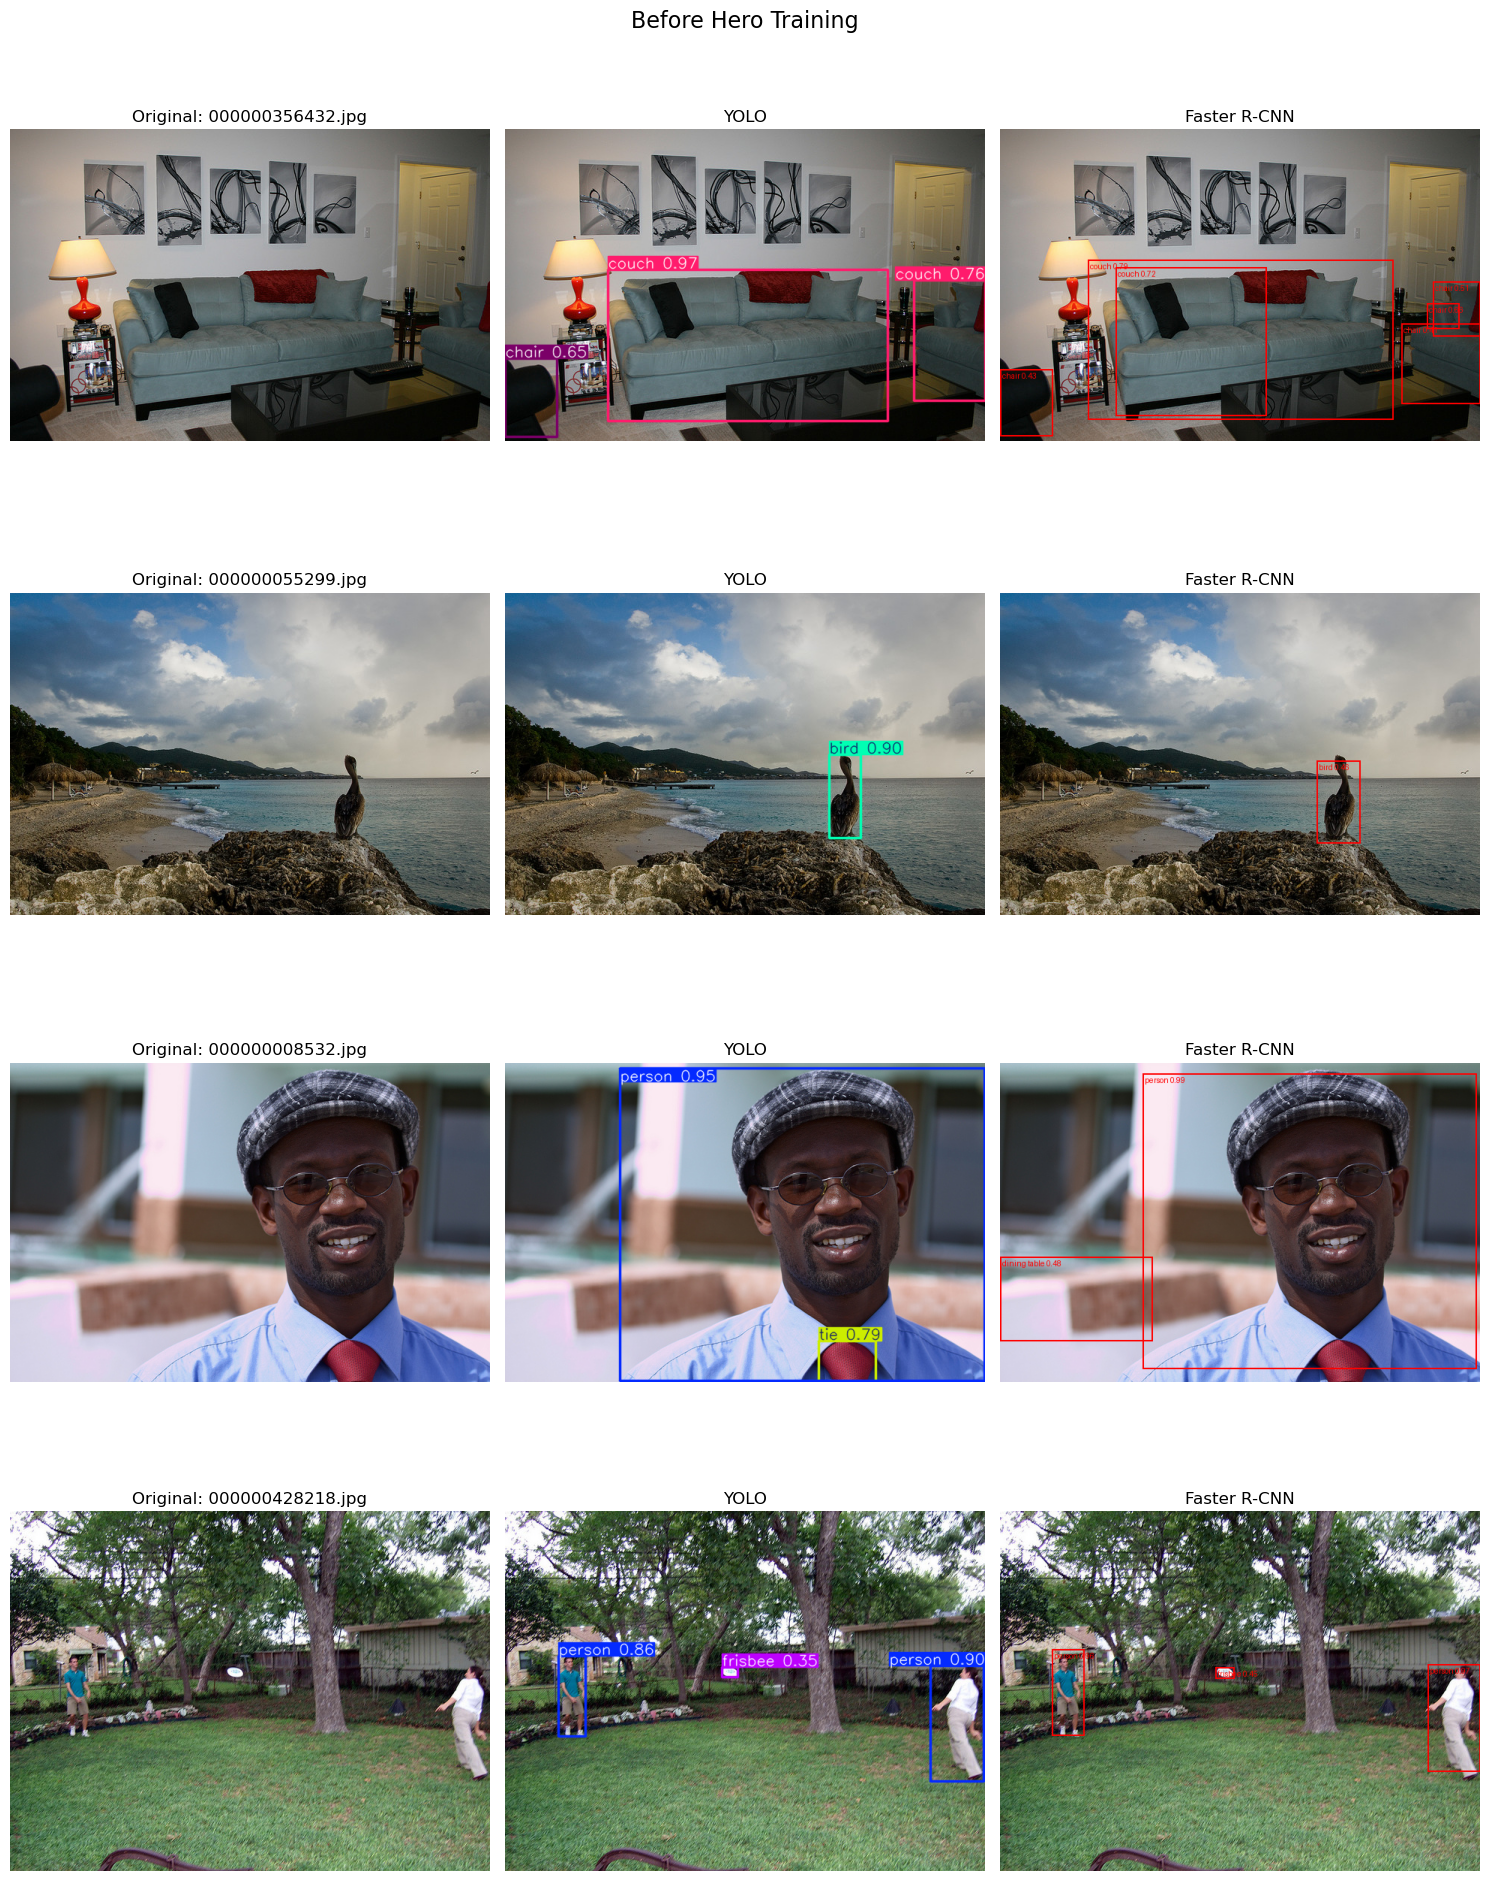

Saved BEFORE visuals to: c:\Users\Magz8\OneDrive\Documents\GitHub\COCO Object Detection\runs\qualitative_hero\before


In [7]:
# ----------------------------------------
# BEFORE: qualitative predictions (fixed set)
# ----------------------------------------
fixed_images = choose_fixed_images(YOLO_VAL_IMAGES if YOLO_VAL_IMAGES.exists() else VAL_IMG_DIR, NUM_VIS_IMAGES, seed=SEED)
print('Fixed images:')
for p in fixed_images:
    print('-', p.name)

before_yolo = []
before_frcnn = []

for img_path in fixed_images:
    yimg = infer_yolo_on_image(yolo_model, img_path, conf=YOLO_CONF)
    fimg = infer_frcnn_on_image(frcnn_model, img_path, COCO_NAMES, score_thresh=FRCNN_CONF)
    before_yolo.append(yimg)
    before_frcnn.append(fimg)

    Image.fromarray(yimg).save(BEFORE_DIR / f'{img_path.stem}_yolo_before.jpg')
    Image.fromarray(fimg).save(BEFORE_DIR / f'{img_path.stem}_frcnn_before.jpg')

show_triplets(fixed_images, before_yolo, before_frcnn, 'Before Hero Training')
print('Saved BEFORE visuals to:', BEFORE_DIR)

## Optional Hero Training (set RUN_HERO=True)

This cell continues both models from their current checkpoints.
- YOLO: resumes to `HERO_TOTAL_EPOCHS` in the same run directory.
- Faster R-CNN: performs additional epochs using your COCO train split paths.

If your COCO files are not found, update `TRAIN_IMG_DIR` / `TRAIN_ANN` manually above.

In [8]:
RUN_HERO = True

COCO80_TO_91 = [
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 13, 14, 15, 16, 17, 18, 19, 20, 21,
    22, 23, 24, 25, 27, 28, 31, 32, 33, 34,
    35, 36, 37, 38, 39, 40, 41, 42, 43, 44,
    46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
    56, 57, 58, 59, 60, 61, 62, 63, 64, 65,
    67, 70, 72, 73, 74, 75, 76, 77, 78, 79,
    80, 81, 82, 84, 85, 86, 87, 88, 89, 90,
]
COCO91_TO_80 = {cid: i + 1 for i, cid in enumerate(COCO80_TO_91)}


class CocoDetectionDataset(Dataset):
    def __init__(self, images_dir: Path, annotations_file: Path):
        self.images_dir = Path(images_dir)
        self.coco = COCO(str(annotations_file))
        self.image_ids = sorted(self.coco.getImgIds())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = self.coco.loadImgs([image_id])[0]
        image_path = self.images_dir / info['file_name']

        image = Image.open(image_path).convert('RGB')
        image_tensor = TF.pil_to_tensor(image).float() / 255.0

        ann_ids = self.coco.getAnnIds(imgIds=[image_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for a in anns:
            x, y, w, h = a['bbox']
            if w <= 1 or h <= 1:
                continue
            sparse_cat = int(a['category_id'])
            if sparse_cat not in COCO91_TO_80:
                continue
            boxes.append([x, y, x + w, y + h])
            labels.append(int(COCO91_TO_80[sparse_cat]))
            areas.append(float(a.get('area', w * h)))
            iscrowd.append(int(a.get('iscrowd', 0)))

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([image_id], dtype=torch.int64),
            'area': areas,
            'iscrowd': iscrowd,
        }
        return image_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


def continue_train_frcnn(checkpoint_path: Path, out_checkpoint: Path):
    if not TRAIN_IMG_DIR.exists() or not TRAIN_ANN.exists():
        raise FileNotFoundError('COCO train image/annotation paths not found. Update TRAIN_IMG_DIR and TRAIN_ANN.')

    ckpt = torch.load(checkpoint_path, map_location='cpu')
    model = build_frcnn_resnet50(num_classes=81, image_size=IMG_SIZE).to(DEVICE)
    model_state = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
    model.load_state_dict(model_state, strict=False)

    optimizer = torch.optim.SGD(model.parameters(), lr=FRCNN_EXTRA_LR, momentum=0.9, weight_decay=1e-4)
    if isinstance(ckpt, dict) and 'optimizer' in ckpt:
        try:
            optimizer.load_state_dict(ckpt['optimizer'])
        except Exception as e:
            print('Optimizer state load skipped:', e)

    start_epoch = int(ckpt.get('epoch', 0)) if isinstance(ckpt, dict) else 0
    extra_epochs = max(0, HERO_TOTAL_EPOCHS - max(BASE_EPOCHS, start_epoch))

    if extra_epochs == 0:
        print(f'No extra FRCNN epochs needed. Checkpoint epoch={start_epoch} already at/above target.')
        return checkpoint_path

    ds = CocoDetectionDataset(TRAIN_IMG_DIR, TRAIN_ANN)
    dl = DataLoader(
        ds,
        batch_size=FRCNN_BATCH,
        shuffle=True,
        num_workers=0,
        collate_fn=collate_fn,
        pin_memory=torch.cuda.is_available(),
    )

    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
    model.train()

    print(f'FRCNN resume source: {checkpoint_path}')
    print(f'FRCNN extra epochs: {extra_epochs} (from epoch {start_epoch} to {HERO_TOTAL_EPOCHS})')
    for ep in range(extra_epochs):
        t0 = time.time()
        running_loss = 0.0
        for images, targets in dl:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                loss_dict = model(images, targets)
                loss = sum(v for v in loss_dict.values())

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += float(loss.item())

        epoch_num = start_epoch + ep + 1
        print(f'FRCNN epoch {epoch_num}/{HERO_TOTAL_EPOCHS} | loss={running_loss/max(1, len(dl)):.4f} | {time.time()-t0:.1f}s')

        torch.save(
            {
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'epoch': epoch_num,
                'saved_at': time.time(),
            },
            out_checkpoint,
        )

    print('Saved/updated hero FRCNN checkpoint at:', out_checkpoint)
    return out_checkpoint


hero_frcnn_ckpt = RUNS_DIR / 'fasterrcnn_resnet50_sgd' / 'checkpoints' / 'hero_latest.pt'
YOLO_HERO_DIR = RUNS_DIR / 'detect' / 'runs' / 'yolo_resnet50_sgd_hero'
YOLO_HERO_LAST = YOLO_HERO_DIR / 'weights' / 'last.pt'
YOLO_HERO_BEST = YOLO_HERO_DIR / 'weights' / 'best.pt'
YOLO_HERO_RESULTS = YOLO_HERO_DIR / 'results.csv'


def yolo_hero_completed(results_csv: Path, target_epochs: int) -> bool:
    if not results_csv.exists():
        return False
    try:
        hist = pd.read_csv(results_csv)
        if 'epoch' not in hist.columns or len(hist) == 0:
            return False
        return int(hist['epoch'].max()) >= (target_epochs - 1)
    except Exception:
        return False


if RUN_HERO:
    if not YOLO_LAST.exists():
        raise FileNotFoundError(f'YOLO last checkpoint missing: {YOLO_LAST}')
    if not YOLO_DATA_YAML.exists():
        raise FileNotFoundError(f'YOLO data yaml missing: {YOLO_DATA_YAML}')

    yolo_done = yolo_hero_completed(YOLO_HERO_RESULTS, HERO_TOTAL_EPOCHS)
    if yolo_done:
        print(f'YOLO hero run already reached epoch {HERO_TOTAL_EPOCHS}; skipping YOLO training step.')
    else:
        yolo_source = YOLO_HERO_LAST if YOLO_HERO_LAST.exists() else YOLO_LAST
        yolo_resume_flag = YOLO_HERO_LAST.exists()

        print(f'YOLO source checkpoint: {yolo_source}')
        print(f'YOLO resume flag: {yolo_resume_flag}')
        yolo_model = YOLO(str(yolo_source))
        yolo_model.train(
            data=str(YOLO_DATA_YAML),
            epochs=HERO_TOTAL_EPOCHS,
            imgsz=IMG_SIZE,
            resume=yolo_resume_flag,
            project=str(RUNS_DIR / 'detect' / 'runs'),
            name='yolo_resnet50_sgd_hero',
            exist_ok=True,
            verbose=True,
        )

    print('Continuing Faster R-CNN hero training...')
    frcnn_source = hero_frcnn_ckpt if hero_frcnn_ckpt.exists() else FRCNN_CKPT
    hero_frcnn_ckpt = continue_train_frcnn(frcnn_source, hero_frcnn_ckpt)
else:
    print('RUN_HERO=False, skipping extra training.')

YOLO hero run already reached epoch 30; skipping YOLO training step.
Continuing Faster R-CNN hero training...
loading annotations into memory...
Done (t=0.70s)
creating index...
index created!
FRCNN resume source: c:\Users\Magz8\OneDrive\Documents\GitHub\COCO Object Detection\runs\fasterrcnn_resnet50_sgd\checkpoints\latest.pt
FRCNN extra epochs: 20 (from epoch 10 to 30)
FRCNN epoch 11/30 | loss=0.7794 | 654.7s
FRCNN epoch 12/30 | loss=0.7457 | 611.4s
FRCNN epoch 13/30 | loss=0.7294 | 600.1s
FRCNN epoch 14/30 | loss=0.7154 | 589.8s
FRCNN epoch 15/30 | loss=0.7000 | 588.8s
FRCNN epoch 16/30 | loss=0.6985 | 587.5s
FRCNN epoch 17/30 | loss=0.6894 | 587.5s
FRCNN epoch 18/30 | loss=0.6885 | 589.2s
FRCNN epoch 19/30 | loss=0.6811 | 592.5s
FRCNN epoch 20/30 | loss=0.6800 | 590.1s
FRCNN epoch 21/30 | loss=0.6768 | 590.5s
FRCNN epoch 22/30 | loss=0.6734 | 590.9s
FRCNN epoch 23/30 | loss=0.6722 | 591.1s
FRCNN epoch 24/30 | loss=0.6675 | 589.7s
FRCNN epoch 25/30 | loss=0.6614 | 587.0s
FRCNN epoch 

In [ ]:
# ---------------------------------------
# AFTER: rerun on the same fixed images
# ---------------------------------------
YOLO_HERO_DIR = RUNS_DIR / 'detect' / 'runs' / 'yolo_resnet50_sgd_hero'
hero_yolo_best = YOLO_HERO_DIR / 'weights' / 'best.pt'
hero_yolo_last = YOLO_HERO_DIR / 'weights' / 'last.pt'

# Prefer hero run weights if they exist, otherwise fallback to base run.
post_yolo_path = YOLO_BEST
if hero_yolo_best.exists():
    post_yolo_path = hero_yolo_best
elif hero_yolo_last.exists():
    post_yolo_path = hero_yolo_last
else:
    candidate_yolo_best = YOLO_RUN_DIR / 'weights' / 'best.pt'
    candidate_yolo_last = YOLO_RUN_DIR / 'weights' / 'last.pt'
    if candidate_yolo_best.exists():
        post_yolo_path = candidate_yolo_best
    elif candidate_yolo_last.exists():
        post_yolo_path = candidate_yolo_last

post_frcnn_path = RUNS_DIR / 'fasterrcnn_resnet50_sgd' / 'checkpoints' / 'hero_latest.pt'
if not post_frcnn_path.exists():
    post_frcnn_path = FRCNN_CKPT

post_yolo_model = YOLO(str(post_yolo_path))
post_frcnn_ckpt = torch.load(post_frcnn_path, map_location='cpu')
post_frcnn_model = build_frcnn_resnet50(num_classes=81, image_size=IMG_SIZE)
post_state = post_frcnn_ckpt['model'] if isinstance(post_frcnn_ckpt, dict) and 'model' in post_frcnn_ckpt else post_frcnn_ckpt
post_frcnn_model.load_state_dict(post_state, strict=False)
post_frcnn_model.to(DEVICE).eval()

print('Using post-hero YOLO weights:', post_yolo_path)
print('Using post-hero FRCNN checkpoint:', post_frcnn_path)

after_yolo = []
after_frcnn = []

for img_path in fixed_images:
    yimg = infer_yolo_on_image(post_yolo_model, img_path, conf=YOLO_CONF)
    fimg = infer_frcnn_on_image(post_frcnn_model, img_path, COCO_NAMES, score_thresh=FRCNN_CONF)

    after_yolo.append(yimg)
    after_frcnn.append(fimg)

    Image.fromarray(yimg).save(AFTER_DIR / f'{img_path.stem}_yolo_after.jpg')
    Image.fromarray(fimg).save(AFTER_DIR / f'{img_path.stem}_frcnn_after.jpg')

show_triplets(fixed_images, after_yolo, after_frcnn, 'After Hero Training (or Latest Available)')
print('Saved AFTER visuals to:', AFTER_DIR)

In [ ]:
# ---------------------------------------------------
# Create side-by-side BEFORE vs AFTER panels per image
# ---------------------------------------------------
for i, img_path in enumerate(fixed_images):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].imshow(before_yolo[i])
    axes[0, 0].set_title('YOLO - Before')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(after_yolo[i])
    axes[0, 1].set_title('YOLO - After')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(before_frcnn[i])
    axes[1, 0].set_title('Faster R-CNN - Before')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(after_frcnn[i])
    axes[1, 1].set_title('Faster R-CNN - After')
    axes[1, 1].axis('off')

    fig.suptitle(f'Qualitative Comparison: {img_path.name}', fontsize=14)
    plt.tight_layout()
    out_path = PANEL_DIR / f'{img_path.stem}_panel.jpg'
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()

print('Saved report-ready comparison panels to:', PANEL_DIR)

## Quantitative Companion: Before/After AP Delta

This section runs fresh validation evaluation for both model families and plots AP changes:
- AP@[.50:.95]
- AP50
- AP75

Tip: Keep BEFORE and AFTER checkpoint paths explicit for reproducibility in your report.

In [ ]:
# Fresh AP evaluation + delta plot on NON-SAMPLED held-out TEST split
from pycocotools.cocoeval import COCOeval
import matplotlib.pyplot as plt
import numpy as np

COCO80_TO_91 = [
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 13, 14, 15, 16, 17, 18, 19, 20, 21,
    22, 23, 24, 25, 27, 28, 31, 32, 33, 34,
    35, 36, 37, 38, 39, 40, 41, 42, 43, 44,
    46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
    56, 57, 58, 59, 60, 61, 62, 63, 64, 65,
    67, 70, 72, 73, 74, 75, 76, 77, 78, 79,
    80, 81, 82, 84, 85, 86, 87, 88, 89, 90,
]

# ---------- configurable settings ----------
TEST_SEED = 42
TEST_SIZE = 500

# Keep consistent with training artifacts
SAMPLED_TRAIN_DIR = RUNS_DIR / 'yolo_resnet50_sgd' / 'yolo_data' / 'train' / 'images'
YOLO_HERO_DIR = RUNS_DIR / 'detect' / 'runs' / 'yolo_resnet50_sgd_hero'

YOLO_BEFORE_WEIGHTS = YOLO_BEST
YOLO_AFTER_WEIGHTS = YOLO_HERO_DIR / 'weights' / 'best.pt'
if not YOLO_AFTER_WEIGHTS.exists():
    yolo_after_last = YOLO_HERO_DIR / 'weights' / 'last.pt'
    YOLO_AFTER_WEIGHTS = yolo_after_last if yolo_after_last.exists() else YOLO_BEFORE_WEIGHTS

FRCNN_BEFORE_CKPT = FRCNN_CKPT
FRCNN_AFTER_CKPT = RUNS_DIR / 'fasterrcnn_resnet50_sgd' / 'checkpoints' / 'hero_latest.pt'
if not FRCNN_AFTER_CKPT.exists():
    FRCNN_AFTER_CKPT = FRCNN_BEFORE_CKPT


def build_non_sampled_test_ids(train_ann: Path, sampled_train_dir: Path, test_size: int = 500, seed: int = 42):
    coco = COCO(str(train_ann))
    id_to_info = {img['id']: img for img in coco.dataset['images']}

    sampled_files = {p.name for p in sampled_train_dir.glob('*.jpg')}
    if len(sampled_files) == 0:
        sampled_files = {p.name for p in sampled_train_dir.glob('*.png')}

    non_sampled_ids = [
        img_id for img_id, info in id_to_info.items()
        if info['file_name'] not in sampled_files
    ]

    rng = random.Random(seed)
    rng.shuffle(non_sampled_ids)
    n = min(test_size, len(non_sampled_ids))
    return coco, sorted(non_sampled_ids[:n]), {
        'seed': seed,
        'requested_test_size': test_size,
        'actual_test_size': n,
        'total_train_images': len(id_to_info),
        'sampled_train_images': len(sampled_files),
        'non_sampled_pool': len(non_sampled_ids),
    }


def coco_eval(coco_gt, preds, img_ids):
    if len(preds) == 0:
        return {'ap': 0.0, 'ap50': 0.0, 'ap75': 0.0}
    coco_dt = coco_gt.loadRes(preds)
    evaluator = COCOeval(coco_gt, coco_dt, iouType='bbox')
    evaluator.params.imgIds = img_ids
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()
    s = evaluator.stats
    return {'ap': float(s[0]), 'ap50': float(s[1]), 'ap75': float(s[2])}


def load_frcnn_from_checkpoint(ckpt_path: Path, image_size: int = 512):
    ckpt = torch.load(ckpt_path, map_location='cpu')
    model = build_frcnn_resnet50(num_classes=81, image_size=image_size)
    state = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
    model.load_state_dict(state, strict=False)
    model.to(DEVICE).eval()
    return model


def evaluate_yolo_on_ids(weights_path: Path, coco_gt, img_ids):
    model = YOLO(str(weights_path))
    preds = []
    for img_id in img_ids:
        info = coco_gt.loadImgs([img_id])[0]
        image_path = TRAIN_IMG_DIR / info['file_name']
        if not image_path.exists():
            continue

        res = model.predict(source=str(image_path), conf=0.001, iou=0.7, verbose=False)[0]
        if res.boxes is None or len(res.boxes) == 0:
            continue

        xyxy = res.boxes.xyxy.cpu().numpy()
        confs = res.boxes.conf.cpu().numpy()
        classes = res.boxes.cls.cpu().numpy().astype(int)

        for b, s, c in zip(xyxy, confs, classes):
            if c < 0 or c >= len(COCO80_TO_91):
                continue
            x1, y1, x2, y2 = b.tolist()
            w = max(0.0, x2 - x1)
            h = max(0.0, y2 - y1)
            if w <= 0 or h <= 0:
                continue
            preds.append({
                'image_id': int(img_id),
                'category_id': int(COCO80_TO_91[c]),
                'bbox': [float(x1), float(y1), float(w), float(h)],
                'score': float(s),
            })

    return coco_eval(coco_gt, preds, img_ids)


@torch.inference_mode()
def evaluate_frcnn_on_ids(model, coco_gt, img_ids, score_thresh=0.001):
    preds = []
    for img_id in img_ids:
        info = coco_gt.loadImgs([img_id])[0]
        image_path = TRAIN_IMG_DIR / info['file_name']
        if not image_path.exists():
            continue

        pil = Image.open(image_path).convert('RGB')
        inp = TF.pil_to_tensor(pil).float() / 255.0
        out = model([inp.to(DEVICE)])[0]

        boxes = out['boxes'].detach().cpu().numpy()
        scores = out['scores'].detach().cpu().numpy()
        labels = out['labels'].detach().cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            if float(score) < score_thresh:
                continue
            if int(label) <= 0 or int(label) > len(COCO80_TO_91):
                continue
            x1, y1, x2, y2 = box.tolist()
            w = max(0.0, x2 - x1)
            h = max(0.0, y2 - y1)
            if w <= 0 or h <= 0:
                continue
            preds.append({
                'image_id': int(img_id),
                'category_id': int(COCO80_TO_91[int(label) - 1]),
                'bbox': [float(x1), float(y1), float(w), float(h)],
                'score': float(score),
            })

    return coco_eval(coco_gt, preds, img_ids)


# Build reproducible non-sampled test split
coco_test_gt, test_ids, split_info = build_non_sampled_test_ids(
    TRAIN_ANN,
    SAMPLED_TRAIN_DIR,
    test_size=TEST_SIZE,
    seed=TEST_SEED,
)

print('Non-sampled test split info:')
for k, v in split_info.items():
    print(f'  {k}: {v}')

# Evaluate BEFORE
print('\nEvaluating YOLO before on non-sampled test...')
yolo_before = evaluate_yolo_on_ids(YOLO_BEFORE_WEIGHTS, coco_test_gt, test_ids)
print('YOLO before:', yolo_before)

print('\nEvaluating Faster R-CNN before on non-sampled test...')
frcnn_before_model = load_frcnn_from_checkpoint(FRCNN_BEFORE_CKPT, IMG_SIZE)
frcnn_before = evaluate_frcnn_on_ids(frcnn_before_model, coco_test_gt, test_ids)
print('FRCNN before:', frcnn_before)

# Evaluate AFTER
print('\nEvaluating YOLO after on non-sampled test...')
yolo_after = evaluate_yolo_on_ids(YOLO_AFTER_WEIGHTS, coco_test_gt, test_ids)
print('YOLO after:', yolo_after)

print('\nEvaluating Faster R-CNN after on non-sampled test...')
frcnn_after_model = load_frcnn_from_checkpoint(FRCNN_AFTER_CKPT, IMG_SIZE)
frcnn_after = evaluate_frcnn_on_ids(frcnn_after_model, coco_test_gt, test_ids)
print('FRCNN after:', frcnn_after)

rows = [
    {'model': 'YOLO', 'phase': 'before', **yolo_before},
    {'model': 'YOLO', 'phase': 'after', **yolo_after},
    {'model': 'Faster R-CNN', 'phase': 'before', **frcnn_before},
    {'model': 'Faster R-CNN', 'phase': 'after', **frcnn_after},
]
metrics_df = pd.DataFrame(rows)

delta_rows = []
for model_name in ['YOLO', 'Faster R-CNN']:
    b = metrics_df[(metrics_df['model'] == model_name) & (metrics_df['phase'] == 'before')].iloc[0]
    a = metrics_df[(metrics_df['model'] == model_name) & (metrics_df['phase'] == 'after')].iloc[0]
    delta_rows.append({
        'model': model_name,
        'delta_ap': a['ap'] - b['ap'],
        'delta_ap50': a['ap50'] - b['ap50'],
        'delta_ap75': a['ap75'] - b['ap75'],
    })
delta_df = pd.DataFrame(delta_rows)

print('\nRaw metrics (non-sampled test):')
display(metrics_df)
print('Deltas (after - before):')
display(delta_df)

# Save tables
metrics_df.to_csv(VIS_DIR / 'hero_test_eval_metrics.csv', index=False)
delta_df.to_csv(VIS_DIR / 'hero_test_eval_deltas.csv', index=False)
with open(VIS_DIR / 'hero_test_split_info.json', 'w', encoding='utf-8') as f:
    json.dump(split_info, f, indent=2)

# Plot grouped bars for before/after
plot_metrics = ['ap', 'ap50', 'ap75']
for m in plot_metrics:
    fig, ax = plt.subplots(figsize=(7, 4))
    subset = metrics_df.pivot(index='model', columns='phase', values=m).loc[['YOLO', 'Faster R-CNN']]
    x = np.arange(len(subset.index))
    width = 0.35
    ax.bar(x - width / 2, subset['before'].values, width, label='Before')
    ax.bar(x + width / 2, subset['after'].values, width, label='After')
    ax.set_xticks(x)
    ax.set_xticklabels(subset.index)
    ax.set_ylabel(m.upper())
    ax.set_title(f'Non-sampled Test: Before vs After {m.upper()}')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    fig.tight_layout()
    fig.savefig(VIS_DIR / f'hero_test_before_after_{m}.png', dpi=180)
    plt.show()

# Plot delta bars
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(delta_df['model']))
width = 0.25
ax.bar(x - width, delta_df['delta_ap'].values, width, label='Delta AP')
ax.bar(x, delta_df['delta_ap50'].values, width, label='Delta AP50')
ax.bar(x + width, delta_df['delta_ap75'].values, width, label='Delta AP75')
ax.axhline(0.0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(delta_df['model'])
ax.set_ylabel('After - Before')
ax.set_title('Hero Run Deltas on Non-sampled Test')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.35)
fig.tight_layout()
fig.savefig(VIS_DIR / 'hero_test_ap_deltas.png', dpi=180)
plt.show()

print('Saved non-sampled test metrics and plots in:', VIS_DIR)